In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("../../data/US-pumpkins.csv")
data = data[data['Package'].str.contains('bushel', case=True, regex=True)]
print(data.head())

    City Name Type               Package   Variety Sub Variety  Grade  \
70  BALTIMORE  NaN  1 1/9 bushel cartons  PIE TYPE         NaN    NaN   
71  BALTIMORE  NaN  1 1/9 bushel cartons  PIE TYPE         NaN    NaN   
72  BALTIMORE  NaN  1 1/9 bushel cartons  PIE TYPE         NaN    NaN   
73  BALTIMORE  NaN  1 1/9 bushel cartons  PIE TYPE         NaN    NaN   
74  BALTIMORE  NaN  1 1/9 bushel cartons  PIE TYPE         NaN    NaN   

       Date  Low Price  High Price  Mostly Low  ...  Unit of Sale Quality  \
70  9/24/16       15.0        15.0        15.0  ...           NaN     NaN   
71  9/24/16       18.0        18.0        18.0  ...           NaN     NaN   
72  10/1/16       18.0        18.0        18.0  ...           NaN     NaN   
73  10/1/16       17.0        17.0        17.0  ...           NaN     NaN   
74  10/8/16       15.0        15.0        15.0  ...           NaN     NaN   

   Condition Appearance Storage  Crop Repack  Trans Mode  Unnamed: 24  \
70       NaN        NaN  

In [4]:
data.info()


<class 'pandas.DataFrame'>
Index: 415 entries, 70 to 1742
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   City Name        415 non-null    str    
 1   Type             9 non-null      str    
 2   Package          415 non-null    str    
 3   Variety          415 non-null    str    
 4   Sub Variety      248 non-null    str    
 5   Grade            0 non-null      float64
 6   Date             415 non-null    str    
 7   Low Price        415 non-null    float64
 8   High Price       415 non-null    float64
 9   Mostly Low       391 non-null    float64
 10  Mostly High      391 non-null    float64
 11  Origin           415 non-null    str    
 12  Origin District  19 non-null     str    
 13  Item Size        301 non-null    str    
 14  Color            270 non-null    str    
 15  Environment      0 non-null      float64
 16  Unit of Sale     11 non-null     str    
 17  Quality          0 non-null   

In [5]:
data.isnull().sum()


City Name            0
Type               406
Package              0
Variety              0
Sub Variety        167
Grade              415
Date                 0
Low Price            0
High Price           0
Mostly Low          24
Mostly High         24
Origin               0
Origin District    396
Item Size          114
Color              145
Environment        415
Unit of Sale       404
Quality            415
Condition          415
Appearance         415
Storage            415
Crop               415
Repack               0
Trans Mode         415
Unnamed: 24        415
Unnamed: 25        391
dtype: int64

In [6]:
columns_to_select = ["Package", "Low Price", "High Price", "Date"]
data = data.loc[:, columns_to_select]
print(data.head())


                 Package  Low Price  High Price     Date
70  1 1/9 bushel cartons       15.0        15.0  9/24/16
71  1 1/9 bushel cartons       18.0        18.0  9/24/16
72  1 1/9 bushel cartons       18.0        18.0  10/1/16
73  1 1/9 bushel cartons       17.0        17.0  10/1/16
74  1 1/9 bushel cartons       15.0        15.0  10/8/16


In [7]:
data['Avg Price'] = (data['Low Price'] + data['High Price']) / 2
data["Month"] = pd.DatetimeIndex(data['Date']).month

print(data.head())


                 Package  Low Price  High Price     Date  Avg Price  Month
70  1 1/9 bushel cartons       15.0        15.0  9/24/16       15.0      9
71  1 1/9 bushel cartons       18.0        18.0  9/24/16       18.0      9
72  1 1/9 bushel cartons       18.0        18.0  10/1/16       18.0     10
73  1 1/9 bushel cartons       17.0        17.0  10/1/16       17.0     10
74  1 1/9 bushel cartons       15.0        15.0  10/8/16       15.0     10


In [8]:
new_data = data[data['Package'].str.contains('bushel')]

mask_1_19 = new_data['Package'].str.contains('1 1/9')
mask_12 = new_data['Package'].str.contains('1/2')

new_data.loc[mask_1_19, 'Avg Price'] = new_data.loc[mask_1_19, 'Avg Price'] / (1 + 1/9)
new_data.loc[mask_12, 'Avg Price'] = new_data.loc[mask_12, 'Avg Price'] / (1/2)


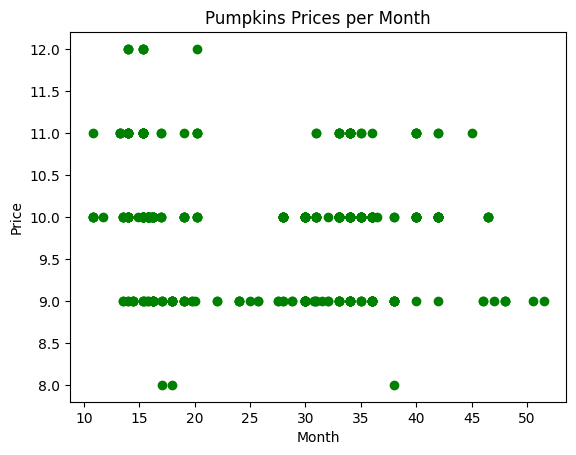

In [9]:

plt.title("Pumpkins Prices per Month")
plt.scatter(new_data["Avg Price"], new_data["Month"], color="green")
plt.xlabel("Month")
plt.ylabel("Price")
plt.show()


Text(0, 0.5, 'Pumpkin Price')

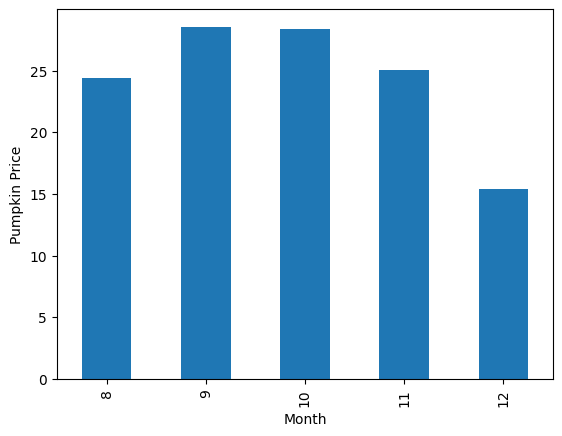

In [10]:
new_data.groupby(['Month'])['Avg Price'].mean().plot(kind='bar')
plt.ylabel("Pumpkin Price")